In [12]:
import sys
import os

functions_path = os.path.abspath(os.path.join('..', 'functions'))
if functions_path not in sys.path:
    sys.path.append(functions_path)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pylab

# Import functions
from data import swiss_roll, swiss_roll_response, simulated_data_loader
from methods import rescaled_gamma_prior_mcmc, knn_prior_mcmc, kernel_ridge_cv

# set the random seed 
np.random.seed(2026)

=== Data range per feature ===
Coordinate 0: min = 0.1841, max = 0.9202
Coordinate 1: min = 0.0000, max = 0.9999
Coordinate 2: min = 0.1320, max = 0.9712


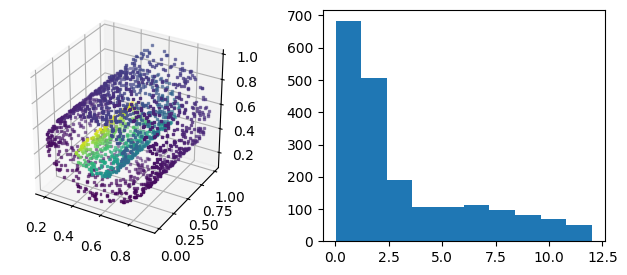

In [14]:
# visualize data and check value range
X, Y_de, Y = swiss_roll(n_data = 20000, sigma_noise = 0.1, f= swiss_roll_response)

print("=== Data range per feature ===")
X_max = np.max(X, axis=0)
X_min = np.min(X, axis=0)
for i, (min_val, max_val) in enumerate(zip(X_min, X_max)):
    print(f"Coordinate {i}: min = {min_val:.4f}, max = {max_val:.4f}")

X, Y_true, Y_noise = swiss_roll(n_data = 2000, f = swiss_roll_response)
x = X[:,0]
y = X[:,1]
z_1 = X[:,2]
colo = Y_true

fig = plt.figure(figsize=(8, 3))
ax = plt.subplot(121, projection='3d')
color_map = pylab.cm.ScalarMappable()
color_map.set_array(colo)  
ax.scatter(x, y, z_1, marker='s', s=2, c= colo)
ax.set_box_aspect([1,1,1])
plt.subplot(122)
plt.hist(Y_true)
plt.show()

In [15]:
# parameters for all baselines

data_loader_kwargs = dict(data_fn= swiss_roll,f_fn= swiss_roll_response)
# data noise level
sigmasq_0 = 0.01

# grid_pos_param of marginal posterior of t
n_grid = 400
left_end = 0.0001 # 10 ** -6
right_end = 0.5
ls_grid_epsilon = np.linspace(left_end, right_end, n_grid)
grid_pos_tolerance = 10**(-10)

#MCMC params
mcmc_time = 3000
burn_in = 1000

# experiment runs
test_size = 2000

# to reproduce results in the paper, use the following setup
#replicas_ls =  [200,200,200,100,100,100]
#train_size_ls = [50,100,200,400,800,1600]

# reduced run times to demo
replicas_ls = [200,200]
train_size_ls = [50, 100] 


In [16]:
#rescaled gamma prior GP
d = 2
a_0 = 1
b_0 = 1 

w_pos_means = []
w_pos_std = []
w_pos_test_means = []
w_pos_test_std = []
dict_log_grid_pos = {}
dict_ls_epsilon = {}

for train_size, replicas in zip(train_size_ls, replicas_ls):
    n_data = train_size + test_size
    ls_w_pos,ls_w_pos_test,dict_log_grid_pos[train_size], dict_ls_epsilon[train_size] = \
                    rescaled_gamma_prior_mcmc(train_size, replicas, n_data, sigmasq_0,
                           n_grid,left_end,right_end, grid_pos_tolerance,
                           a_0, b_0, d, 
                           burn_in, mcmc_time,
                           data_loader=simulated_data_loader,data_loader_kwargs=data_loader_kwargs)
    
    w_pos_means.append(np.mean(ls_w_pos))
    w_pos_std.append(np.std(ls_w_pos))
    w_pos_test_means.append(np.mean(ls_w_pos_test))
    w_pos_test_std.append(np.std(ls_w_pos_test))
    print(f"train_size {train_size}, IS error {np.mean(ls_w_pos)}, OS error {np.mean(ls_w_pos_test)}")

0 replica time: 1.24
proposal: 1.00e-03, start_point: 0.04, err_in: 0.08, err_os: 1.37
1 replica time: 1.25
proposal: 1.00e-03, start_point: 0.03, err_in: 0.08, err_os: 0.70
2 replica time: 1.22
proposal: 1.05e-03, start_point: 0.04, err_in: 0.10, err_os: 1.81
3 replica time: 1.21
proposal: 1.05e-03, start_point: 0.04, err_in: 0.11, err_os: 0.95
4 replica time: 1.23
proposal: 1.05e-03, start_point: 0.04, err_in: 0.10, err_os: 0.78
5 replica time: 1.28
proposal: 1.15e-03, start_point: 0.04, err_in: 0.07, err_os: 1.34
6 replica time: 1.28
proposal: 1.50e-03, start_point: 0.04, err_in: 0.10, err_os: 1.36
7 replica time: 1.22
proposal: 1.00e-03, start_point: 0.04, err_in: 0.11, err_os: 0.81
8 replica time: 1.27
proposal: 1.15e-03, start_point: 0.04, err_in: 0.11, err_os: 0.90
9 replica time: 1.19
proposal: 1.00e-03, start_point: 0.04, err_in: 0.09, err_os: 0.74
10 replica time: 1.22
proposal: 1.05e-03, start_point: 0.04, err_in: 0.11, err_os: 0.89
11 replica time: 1.21
proposal: 1.00e-03, 

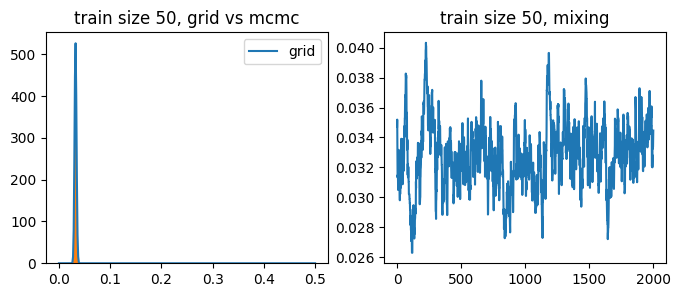

In [17]:
# sanity check of the computed posterior of the reverse gamma prior
train_size = 50
# grid of marginal posterior of t
log_grid_pos = dict_log_grid_pos[train_size]
weight_pos = np.exp(log_grid_pos - np.max(log_grid_pos))
weight_pos = weight_pos/np.sum(weight_pos)

plt.figure(figsize=(8,3))
plt.subplot(121)
plt.plot(ls_grid_epsilon,weight_pos*(mcmc_time-burn_in),label = 'grid')
plt.title(f"train size {train_size}, grid vs mcmc")
plt.hist(dict_ls_epsilon[train_size][burn_in:],bins = ls_grid_epsilon)
plt.legend()
plt.subplot(122)
plt.plot(dict_ls_epsilon[train_size][burn_in:])
plt.title(f"train size {train_size}, mixing")
plt.show()

In [18]:
# knn prior GP
gamma1 = 0.25
gamma2 = 0.25
a_0 = 1
b_0 = 1

w_pos_knn_means = []
w_pos_knn_std = []
w_pos_knn_test_means = []
w_pos_knn_test_std = []
dict_Tn_count = {}
dict_log_grid_pos_knn = {}
dict_ls_epsilon_knn = {}

for train_size, replicas in zip(train_size_ls, replicas_ls):
    n_data = train_size + test_size
    ls_w_pos_knn,ls_w_pos_knn_test, dict_Tn_count[train_size], dict_log_grid_pos_knn[train_size], dict_ls_epsilon_knn[train_size] \
                     = knn_prior_mcmc(train_size, replicas, n_data,sigmasq_0,
                      n_grid, left_end,right_end,grid_pos_tolerance,
                      a_0,b_0, gamma1, gamma2, 
                      burn_in, mcmc_time,
                      data_loader=simulated_data_loader,data_loader_kwargs=data_loader_kwargs,
                      v_hat_method='arithmetic')
    
    w_pos_knn_means.append(np.mean(ls_w_pos_knn))
    w_pos_knn_std.append(np.std(ls_w_pos_knn))
    w_pos_knn_test_means.append(np.mean(ls_w_pos_knn_test))
    w_pos_knn_test_std.append(np.std(ls_w_pos_knn_test))
    print(f"train_size {train_size}, IS error {np.mean(ls_w_pos_knn)}, OS error {np.mean(ls_w_pos_knn_test)}")

0 replica time: 1.50, Tn_count 0
proposal: 1.10e-03, start_point: 0.04, err_in: 0.11, err_os: 1.19
1 replica time: 1.54, Tn_count 0
proposal: 1.05e-03, start_point: 0.03, err_in: 0.12, err_os: 1.13
2 replica time: 1.62, Tn_count 0
proposal: 1.05e-03, start_point: 0.03, err_in: 0.09, err_os: 0.92
3 replica time: 1.68, Tn_count 0
proposal: 1.10e-03, start_point: 0.03, err_in: 0.10, err_os: 1.07
4 replica time: 1.59, Tn_count 0
proposal: 8.02e-04, start_point: 0.03, err_in: 0.11, err_os: 0.95
5 replica time: 1.54, Tn_count 0
proposal: 1.05e-03, start_point: 0.03, err_in: 0.12, err_os: 0.61
6 replica time: 1.54, Tn_count 0
proposal: 9.52e-04, start_point: 0.03, err_in: 0.11, err_os: 0.74
7 replica time: 1.53, Tn_count 0
proposal: 1.25e-03, start_point: 0.04, err_in: 0.10, err_os: 1.25
8 replica time: 1.52, Tn_count 0
proposal: 1.05e-03, start_point: 0.03, err_in: 0.09, err_os: 1.26
9 replica time: 1.53, Tn_count 0
proposal: 1.00e-03, start_point: 0.04, err_in: 0.12, err_os: 1.22
10 replica

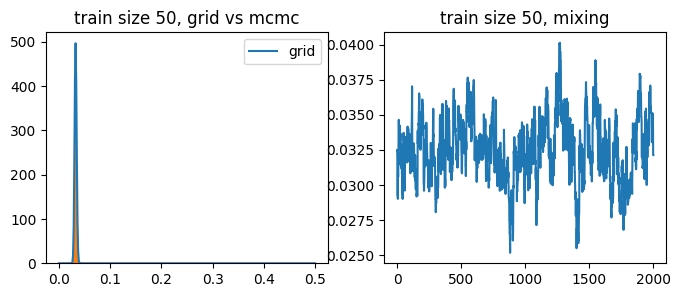

In [19]:
# sanity check of the computed posterior of knn prior
train_size = 50
# grid of marginal posterior of t
log_grid_pos_knn = dict_log_grid_pos_knn[train_size]
weight_pos = np.exp(log_grid_pos_knn - np.max(log_grid_pos_knn))
weight_pos = weight_pos/np.sum(weight_pos)

plt.figure(figsize=(8,3))
plt.subplot(121)
plt.plot(ls_grid_epsilon,weight_pos*(mcmc_time-burn_in),label = 'grid')
plt.title(f"train size {train_size}, grid vs mcmc")
plt.hist(dict_ls_epsilon_knn[train_size][burn_in:],bins = ls_grid_epsilon)
plt.legend()
plt.subplot(122)
plt.plot(dict_ls_epsilon_knn[train_size][burn_in:])
plt.title(f"train size {train_size}, mixing")
plt.show()

In [20]:
#kernel ridge cv
val_percent = 0.1
cv_means = []
cv_std = []
cv_test_means = []
cv_test_std = []
single_means = []
single_std = []
for train_size, replicas in zip(train_size_ls, replicas_ls):
    n_data = train_size + test_size
    ls_kernel_ridge,ls_kernel_ridge_test,ls_single = kernel_ridge_cv(train_size, replicas,val_percent,n_data,sigmasq_0,
                           n_grid, left_end,right_end,
                           data_loader=simulated_data_loader,data_loader_kwargs=data_loader_kwargs)
    cv_means.append(np.mean(ls_kernel_ridge))
    cv_std.append(np.std(ls_kernel_ridge))
    cv_test_means.append(np.mean(ls_kernel_ridge_test))
    cv_test_std.append(np.std(ls_kernel_ridge_test))
    single_means.append(np.mean(ls_single))
    single_std.append(np.std(ls_single))
    print(f"train_size {train_size}, IS error {np.mean(ls_kernel_ridge)}, OS error {np.mean(ls_kernel_ridge_test)}")

0 replica time: 0.16
 err_in: 0.09, err_os: 0.98
1 replica time: 0.16
 err_in: 0.20, err_os: 1.03
2 replica time: 0.17
 err_in: 0.11, err_os: 1.01
3 replica time: 0.17
 err_in: 0.09, err_os: 0.80
4 replica time: 0.17
 err_in: 0.10, err_os: 1.10
5 replica time: 0.16
 err_in: 0.09, err_os: 0.62
6 replica time: 0.17
 err_in: 0.11, err_os: 0.70
7 replica time: 0.17
 err_in: 0.11, err_os: 0.78
8 replica time: 0.17
 err_in: 0.10, err_os: 0.92
9 replica time: 0.17
 err_in: 0.35, err_os: 1.03
10 replica time: 0.17
 err_in: 0.11, err_os: 1.16
11 replica time: 0.17
 err_in: 0.13, err_os: 0.76
12 replica time: 0.17
 err_in: 0.10, err_os: 1.45
13 replica time: 0.16
 err_in: 0.13, err_os: 1.01
14 replica time: 0.17
 err_in: 0.11, err_os: 0.89
15 replica time: 0.16
 err_in: 0.13, err_os: 0.68
16 replica time: 0.17
 err_in: 0.22, err_os: 1.57
17 replica time: 0.16
 err_in: 0.35, err_os: 1.08
18 replica time: 0.17
 err_in: 0.72, err_os: 1.55
19 replica time: 0.18
 err_in: 0.15, err_os: 0.93
20 replica

In [21]:
def format_stats(means, stds, precision=4):
    means_fmt = [f"{m:.{precision}f}" for m in means]
    stds_fmt  = [f"{s:.{precision}f}" for s in stds]
    return ", ".join([f"{m} ± {s}" for m, s in zip(means_fmt, stds_fmt)])


print("\n========== TEST PERFORMANCE ==========")
print(f"KNN-MCMC        : {format_stats(w_pos_knn_test_means, w_pos_knn_test_std)}")
print(f"Rescaled-Gamma  : {format_stats(w_pos_test_means,     w_pos_test_std)}")
print(f"KernelRidge-CV  : {format_stats(cv_test_means,        cv_test_std)}")

print("\n========== TRAIN PERFORMANCE ==========")
print(f"KNN-MCMC        : {format_stats(w_pos_knn_means, w_pos_knn_std)}")
print(f"Rescaled-Gamma  : {format_stats(w_pos_means,     w_pos_std)}")
print(f"KernelRidge-CV  : {format_stats(cv_means,        cv_std)}")


========== TEST PERFORMANCE ==========
KNN-MCMC        : 0.9298 ± 0.2683, 0.4364 ± 0.1284
Rescaled-Gamma  : 0.9087 ± 0.2527, 0.4330 ± 0.1318
KernelRidge-CV  : 1.0832 ± 0.3569, 0.5273 ± 0.2081

========== TRAIN PERFORMANCE ==========
KNN-MCMC        : 0.1015 ± 0.0107, 0.0931 ± 0.0073
Rescaled-Gamma  : 0.1029 ± 0.0108, 0.0937 ± 0.0072
KernelRidge-CV  : 0.1622 ± 0.1258, 0.1248 ± 0.0547


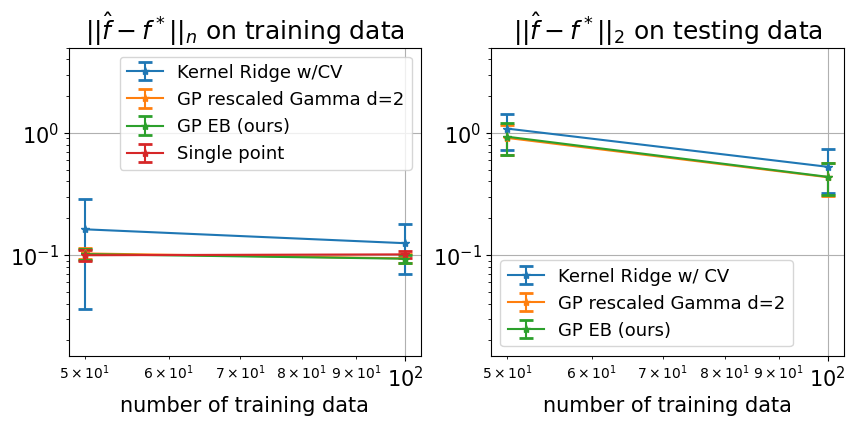

In [22]:
#In-sample-error
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.errorbar(train_size_ls, cv_means, cv_std, linestyle='-', marker='*',label = "Kernel Ridge w/CV" ,capsize=5, capthick=2)
plt.errorbar(train_size_ls, w_pos_means, w_pos_std, linestyle='-', marker='*',label = "GP rescaled Gamma d=2",capsize=5, capthick=2)
plt.errorbar(train_size_ls, w_pos_knn_means, w_pos_knn_std, linestyle='-', marker='*',label = "GP EB (ours)",capsize=5, capthick=2)
plt.errorbar(train_size_ls, single_means, single_std, linestyle='-', marker='*',label = "Single point" ,capsize=5, capthick=2)
plt.xlabel('number of training data', fontsize = 15)
plt.grid()
plt.title(r'$||\hat{f}-f^*||_{n}$ on training data', fontsize = 18)
plt.xscale('log')
plt.yscale('log')
plt.ylim([0.015, 5])
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.legend(fontsize=13)

#Out-of-sample error 
plt.subplot(122)
plt.errorbar(train_size_ls, cv_test_means, cv_test_std, linestyle='-', marker='*',label = "Kernel Ridge w/ CV" ,capsize=5, capthick=2)
plt.errorbar(train_size_ls, w_pos_test_means, w_pos_test_std, linestyle='-', marker='*',label = "GP rescaled Gamma d=2",capsize=5, capthick=2)
plt.errorbar(train_size_ls, w_pos_knn_test_means, w_pos_knn_test_std, linestyle='-', marker='*',label = "GP EB (ours)",capsize=5, capthick=2)
plt.xlabel('number of training data', fontsize = 15)
plt.grid()
plt.title(r'$||\hat{f}-f^*||_{2}$ on testing data', fontsize = 18)
plt.xscale('log')
plt.yscale('log')
plt.ylim([0.015, 5])
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.legend(fontsize = 13)
plt.show()